# calculate duration of each activity

In [5]:
import os

import matplotlib.pyplot as plt

import numpy as np

from deepview.calculate_results.data.umineko_data import (
    read_umineko_data,
read_umineko_path,
extract_data_from_year_back,
label_dict,
get_accel_batch_data,
)

from collections import Counter

In [ ]:
# label_dict = {
#     'ground_stationary': 0,
#     'stationary': 0,
#     'preening': 0,
#     'bathing': 1,
#     'bathing_poss': 1,
#     'flight_take_off': 2,
#     'flight_cruising': 3,
#     'flying_active': 4,
#     'flying_passive': 4,
#     'foraging': 5,
#     'poss_foraging': 5,
#     'foraging_fish_poss': 6,
#     'foraging_insect_poss': 7,
#     'forgaing_insect': 7,
#     'foraging_non-fish': 8,
#     'foraging_steal': 9,
#     'foraging_poss': 9,
#     'foraging_dive': 10,
#     'surface_seizing': 11,
#     'body_shaking': 12,
#     'ground_active': 13,
#     'unknown': 14,  #-1
# }

In [6]:
back_label_path = r'D:\logbot-data\BioTaggerData\masterLabelsByOtsuka\animal_id.csv'
umi_root_path = r'D:\logbot-data\BioTaggerData\export\raw\umineko\v.1.0.0'
file_paths = read_umineko_path(umi_root_path)

year = '2018'
data_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko_%s.npy'%year
if os.path.exists(data_path):
    tmp = np.load(data_path, allow_pickle='TRUE').item()
    df_list = tmp['raw_data']
    df_clean_list = tmp['labeled_data']
    
selected_df, selected_clean_df = (
        extract_data_from_year_back(df_list, df_clean_list, 1))

selected_df['label_id'] = selected_df['label'].map(label_dict)
selected_clean_df['label_id'] = selected_clean_df['label'].map(label_dict)



C:\Users\dell\AppData\Local\Temp\ipykernel_43960\3663547461.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['label_id'] = selected_df['label'].map(label_dict)
C:\Users\dell\AppData\Local\Temp\ipykernel_43960\3663547461.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_clean_df['label_id'] = selected_clean_df['label'].map(label_dict)


In [4]:
import pandas as pd
import numpy as np

# Sample DataFrame
data = {
    'label': [2.0, 2.0, np.nan, 2.5, 2.5, 2.0, 2.0, np.nan, np.nan, 4.0, 4.0, 2.5, np.nan]
}
df = pd.DataFrame(data)

# Define a function to identify segments based on value change
def segment_values(series):
    # Forward fill NaN values to preserve segments
    filled_series = series.ffill()
    
    # Identify changes in the value
    changes = filled_series.diff().ne(0).astype(int)
    
    # Assign a unique segment ID to each group of continuous values
    segments = changes.cumsum()
    
    # Mask the NaNs again to keep them separate
    segments[series.isna()] = np.nan
    
    return segments

# Apply the function to create a new column with segment IDs
df['segment'] = segment_values(df['label'])

# Group segments by unique values
grouped_segments = df.dropna().groupby('label')['segment'].unique()

# Convert the grouped segments to a list of lists for better visualization
grouped_segments_list = {label: list(segments) for label, segments in grouped_segments.items()}

print("Grouped Segments:")
for label, segments in grouped_segments_list.items():
    print(f"Value {label}: Segments {segments}")

Grouped Segments:
Value 2.0: Segments [1.0, 3.0]
Value 2.5: Segments [2.0, 5.0]
Value 4.0: Segments [4.0]


## umineko 2018, back 1, whole data

In [7]:
df = selected_df[['label', 'label_id']].copy()
# Apply the function to create a new column with segment IDs
df['segment'] = segment_values(df['label_id'])

# Group segments by unique values
grouped_segments = df.dropna().groupby('label_id')['segment'].unique()

# Convert the grouped segments to a list of lists for better visualization
grouped_segments_list = {label: list(segments) for label, segments in grouped_segments.items()}

print("Grouped Segments:")
for label, segments in grouped_segments_list.items():
    print(f"Value {label}: Segments {segments}")

Grouped Segments:
Value 0.0: Segments [20940.0, 20942.0, 20944.0, 20946.0, 20954.0, 20956.0, 20958.0, 20964.0, 20966.0, 20968.0, 20971.0, 20973.0, 20979.0, 20981.0, 20983.0, 20991.0, 20993.0, 20995.0, 20998.0, 21000.0, 21004.0, 21006.0, 21013.0, 21015.0, 21018.0, 21020.0, 21026.0, 21028.0, 21030.0, 21032.0, 21034.0, 21036.0, 21038.0, 21040.0, 21043.0, 21046.0, 21055.0, 21058.0, 21071.0, 21073.0, 21077.0, 21079.0, 21083.0, 21085.0, 21088.0, 21090.0, 21092.0, 21095.0, 21116.0, 21121.0, 21124.0, 21132.0, 21134.0, 21136.0, 21138.0, 21142.0, 21144.0, 21146.0, 21148.0, 21160.0, 21162.0, 21164.0, 21166.0, 21175.0, 21206.0, 21208.0, 21210.0, 21220.0, 21222.0, 21237.0, 21247.0, 21249.0, 21251.0, 21256.0, 21258.0, 21260.0, 21262.0, 21264.0, 21266.0, 21268.0, 21272.0, 21274.0, 21276.0, 21278.0, 21281.0, 21283.0, 21285.0, 21293.0, 21295.0, 21297.0, 21299.0, 21301.0, 21303.0, 21305.0, 21307.0, 21309.0, 21314.0, 21321.0, 21331.0, 21335.0, 21338.0, 21345.0, 21347.0, 21349.0, 21351.0, 21353.0, 21355.0

## for every activity, calculate duration

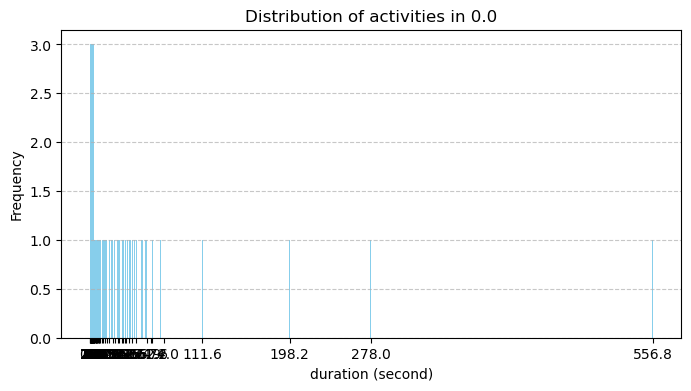

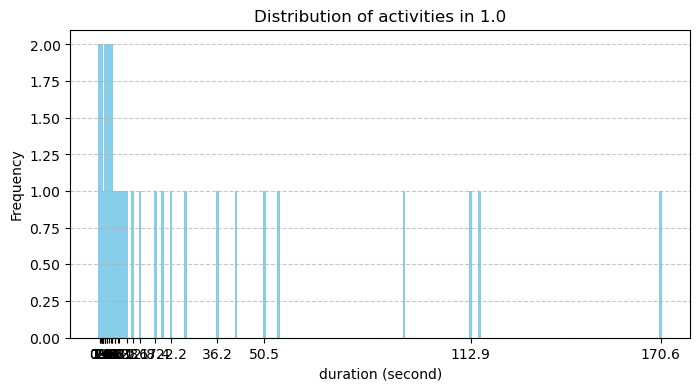

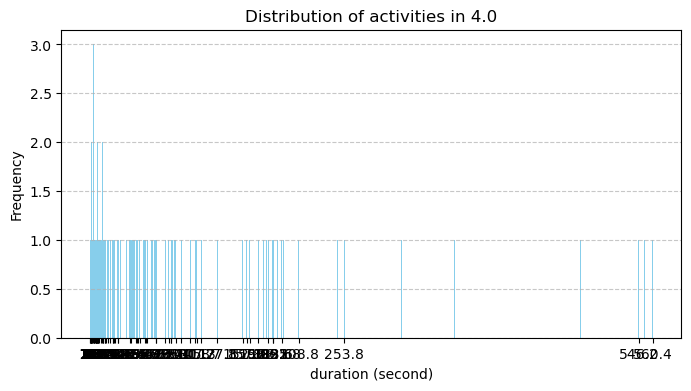

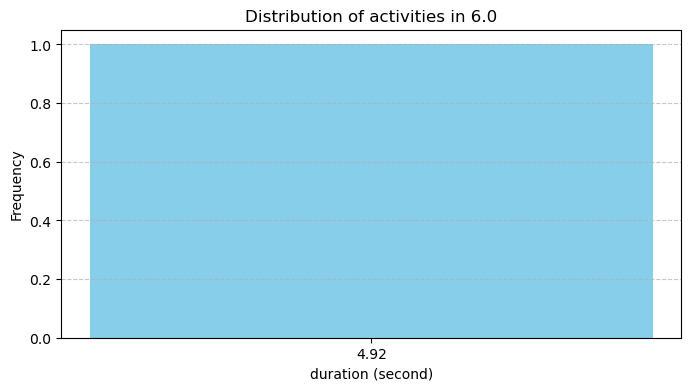

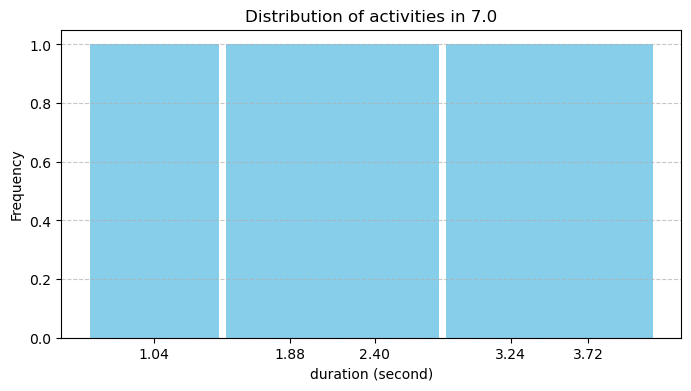

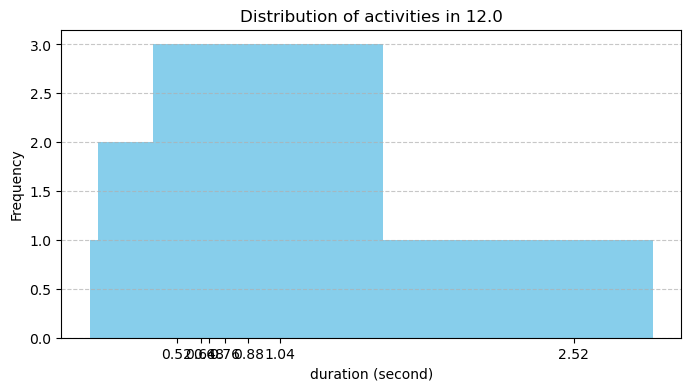

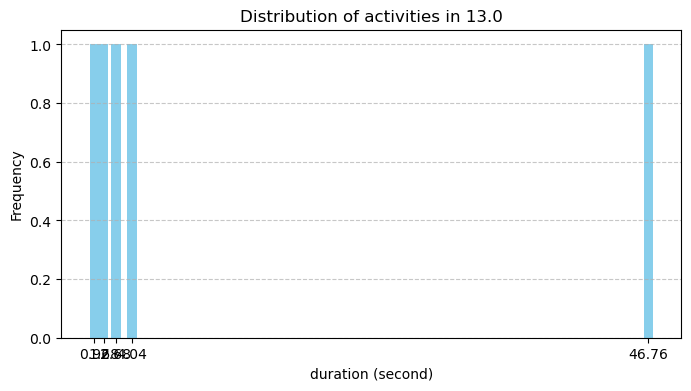

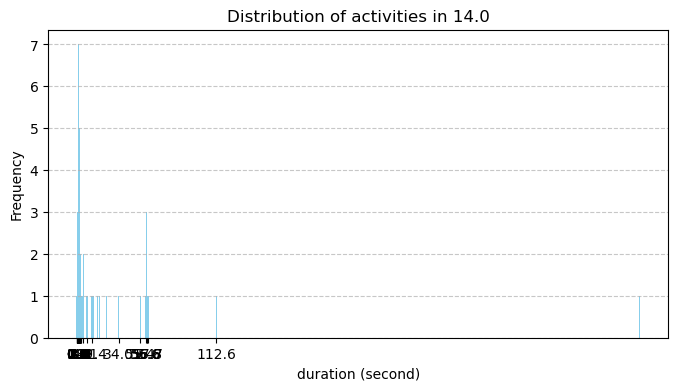

In [14]:
sampling_rate = 25 # hz
activity_duration_dict = {}
for label, segments in grouped_segments_list.items():
    # print(f"Value {label}: Segments {segments}")
    seglens = []
    for seg in segments:
        seglen = len(df[df['segment'] == seg]) / sampling_rate
        seglens.append(seglen)
    activity_duration_dict[label] = seglens

# Plot a bar chart for each key
for key, values in activity_duration_dict.items():
    # Count the frequency of each number in the list
    frequency = Counter(values)
    
    # Create bar chart
    plt.figure(figsize=(8, 4))
    plt.bar(frequency.keys(), frequency.values(), width=0.8, color='skyblue')
    plt.title(f'Distribution of activities in {key}')
    plt.xlabel('duration (second)')
    plt.ylabel('Frequency')
    # plt.xticks(list(frequency.keys()))
    # Display every N-th label
    N = 2  # Change this to select every N-th label
    x_positions = list(frequency.keys())
    if len (x_positions) > 4*N:
        plt.xticks(x_positions[::N])  # Use slicing to select every N-th label
    else:
        plt.xticks(list(frequency.keys()))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

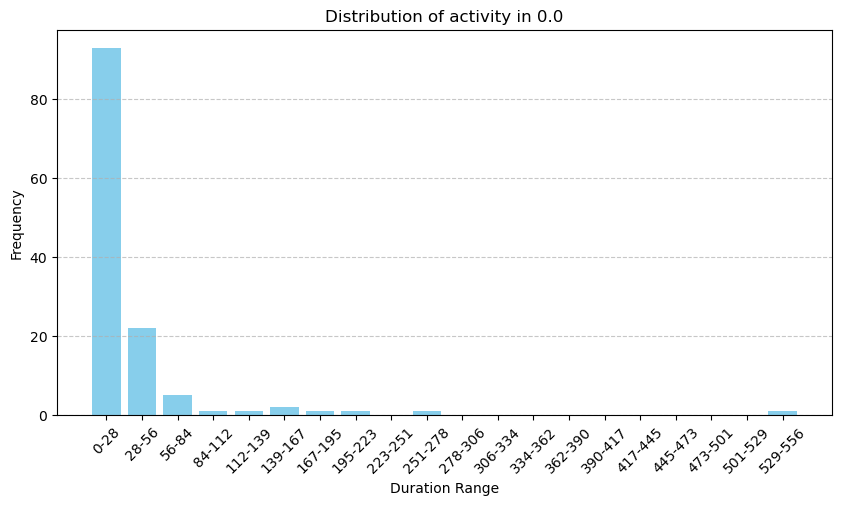

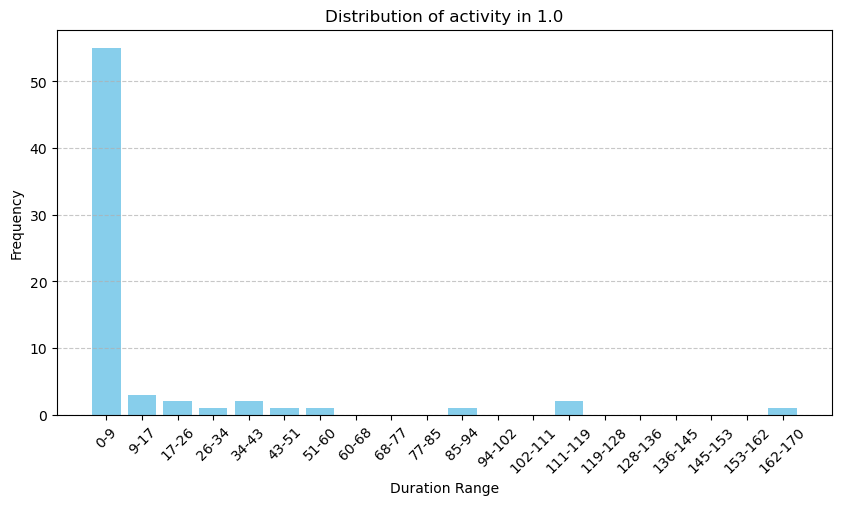

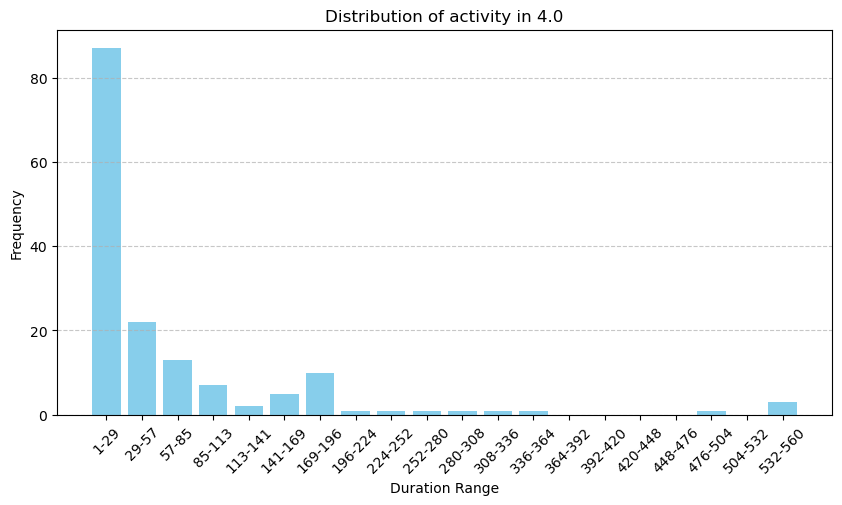

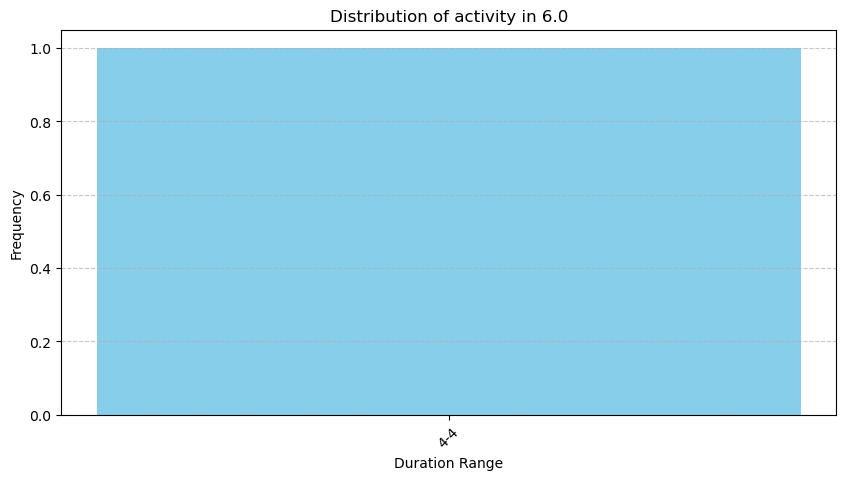

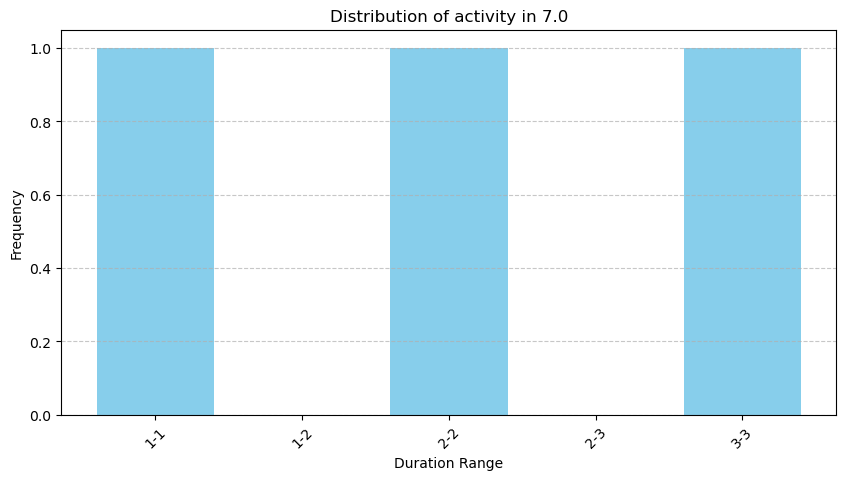

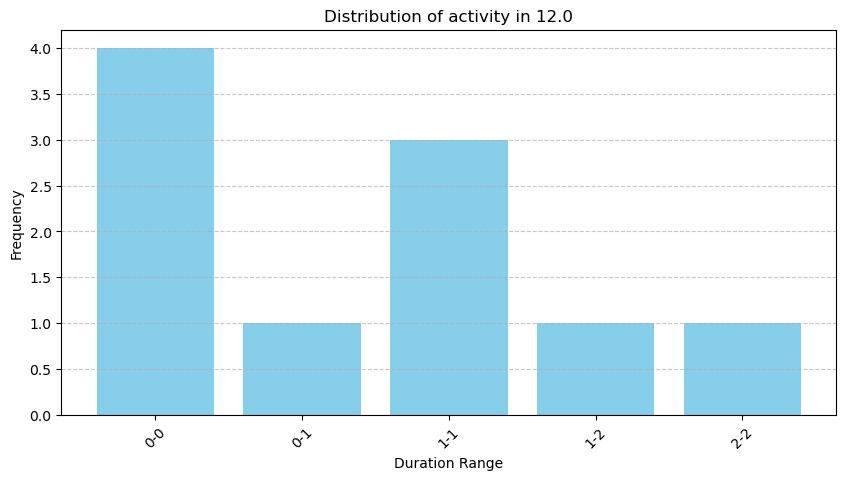

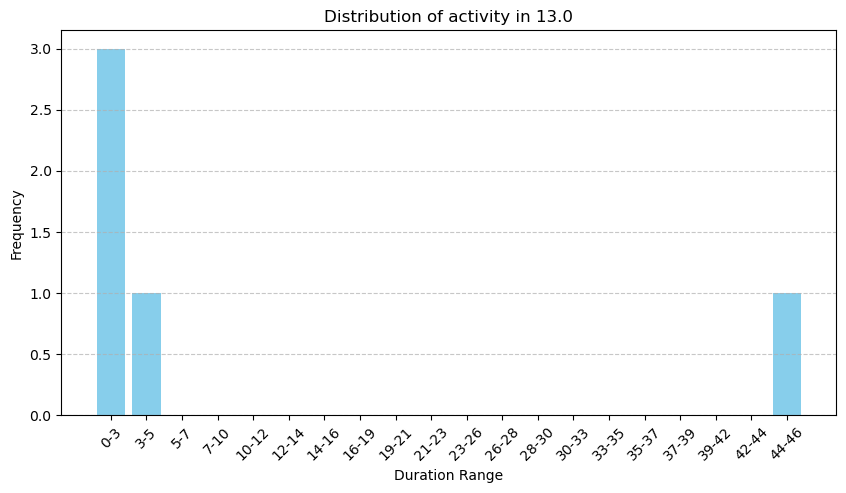

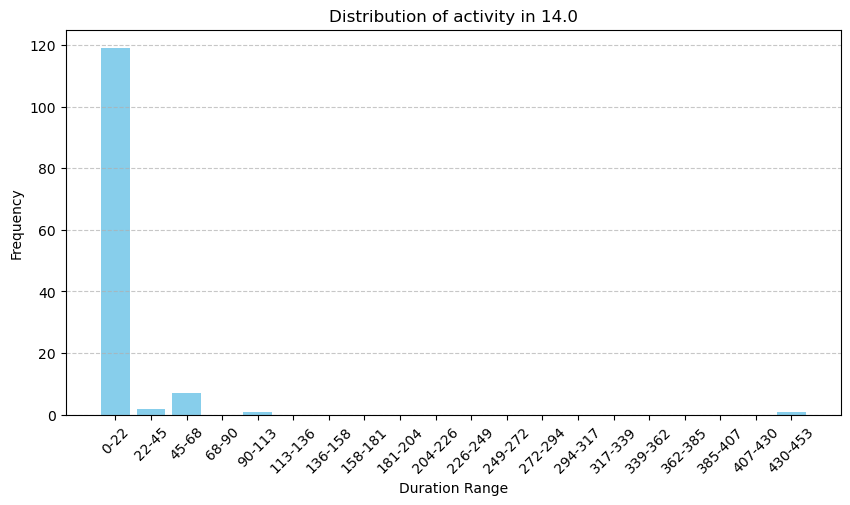

In [19]:
# Define the number of bins
num_bins = 20

# Plot a bar chart for each key
for key, values in activity_duration_dict.items():
    # Calculate the range of values
    min_value = min(values)
    max_value = max(values)
    
    # Create bins
    bins = np.linspace(min_value, max_value, num_bins + 1)
    
    # Count the number of values in each bin
    counts, _ = np.histogram(values, bins=bins)
    
    # Create bin labels
    bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins) - 1)]
    
    # Create a bar chart using the bin labels and counts
    plt.figure(figsize=(10, 5))
    plt.bar(bin_labels, counts, width=0.8, color='skyblue')
    plt.title(f'Distribution of activity in {key}')
    plt.xlabel('Duration Range')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)  # Rotate labels for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()